# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [41]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Padronização/escalonamento
from sklearn.preprocessing import StandardScaler

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de avaliação
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score



---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?
- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

In [42]:
# 1. Carregar o dataset e montar X (features) e y (alvo)
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnostico")  # 0 = maligno, 1 = benigno





In [43]:
print(f"Classes: {list(data.target_names)} -> códigos {sorted(y.unique())}")

# 2. Primeiras linhas
display(X.head())
display(y.head())


Classes: [np.str_('malignant'), np.str_('benign')] -> códigos [np.int64(0), np.int64(1)]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


0    0
1    0
2    0
3    0
4    0
Name: diagnostico, dtype: int64

In [44]:
# 3. Dimensões
print(f"\nAmostras: {X.shape[0]} | Features: {X.shape[1]}")




Amostras: 569 | Features: 30


In [45]:
# 4. Valores ausentes
print(f"Valores ausentes em X: {X.isnull().sum().sum()}")
print(f"Valores ausentes em y: {y.isnull().sum()}")



Valores ausentes em X: 0
Valores ausentes em y: 0


In [46]:
# 5. Balanceamento das classes
print("\nBalanceamento das classes (0 = maligno, 1 = benigno):")
contagem = y.value_counts().rename({0: "maligno", 1: "benigno"})
proporcao = y.value_counts(normalize=True).rename({0: "maligno", 1: "benigno"}) * 100
display(pd.DataFrame({"contagem": contagem, "%": proporcao.round(1)}))




Balanceamento das classes (0 = maligno, 1 = benigno):


,contagem,%
diagnostico,,
benigno,357,62.7
maligno,212,37.3


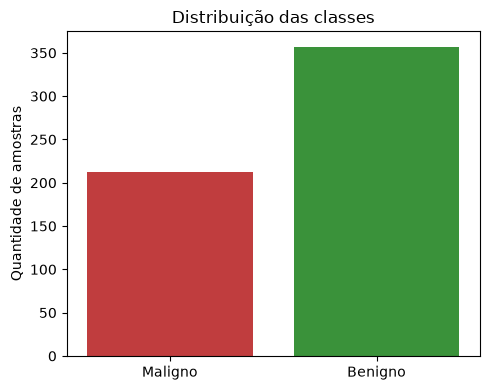

In [47]:
# 6. Gráfico da distribuição das classes
plt.figure(figsize=(5, 4))
sns.countplot(x=y.map({0: "Maligno", 1: "Benigno"}), hue=y.map({0: "Maligno", 1: "Benigno"}),
              palette={"Maligno": "#d62728", "Benigno": "#2ca02c"}, legend=False)
plt.title("Distribuição das classes")
plt.xlabel("")
plt.ylabel("Quantidade de amostras")
plt.tight_layout()
plt.show()


**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?


As classes estão desbalanceadas mas nao de forma tão extrema (62/38), o pior é a baixa quantidade de dados.


- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a diferenciar um tumor maligno de um benigno?



Sem nenhuma ideia de como analisar os dados sem uma reunião tecnica com o corpo medico para eles explicarem como analisar cada coluna e como elas são importantes para a detecção do problema

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [48]:
# 1-2. Split treino/teste estratificado e reprodutível
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% treino / 20% teste
    random_state=42,    # reprodutibilidade
    stratify=y          # mantém a proporção 37% maligno / 63% benigno nos dois conjuntos
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("\nProporção de classes (0=maligno, 1=benigno):")
print("Treino:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Teste: ", y_test.value_counts(normalize=True).round(3).to_dict())

# 3. Escalonamento (StandardScaler) — fit só no treino, para não vazar estatística do teste
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # aprende média/desvio do treino e já transforma
X_test_scaled = scaler.transform(X_test)        # aplica a MESMA escala aprendida no treino


Treino: 455 amostras | Teste: 114 amostras

Proporção de classes (0=maligno, 1=benigno):
Treino: {1: 0.626, 0: 0.374}
Teste:  {1: 0.632, 0: 0.368}


**Respostas (Parte 2):**

**Por que o escalonamento é indispensável no KNN mas não na Árvore?**


O KNN decide a classe de um ponto pela **distância euclidiana** até seus vizinhos. Se as features
ficarem em escalas diferentes (ex: `mean area` na casa das centenas/milhares vs `mean smoothness`
na casa dos décimos), a distância é dominada pela feature de maior magnitude — na prática o modelo
"ignora" as demais. O `StandardScaler` corrige isso colocando todas as features em média 0 e
desvio padrão 1, dando peso justo a cada uma. Já a Árvore de Decisão não usa distância: ela escolhe
cortes tipo `feature <= limiar` que reduzem a impureza de Gini, e esse critério não muda de escala
— cortar em `area <= 500` ou em `area_padronizada <= -0.3` separa exatamente as mesmas amostras.

**O que aconteceria se o scaler fosse ajustado (`fit`) também no teste?**


Seria **data leakage** (vazamento de dados): a média e o desvio padrão usados para padronizar
passariam a incluir informação do conjunto de teste, que deveria ser totalmente desconhecido do
modelo até a hora de avaliar. Isso equivale a "colar a prova antes da prova"  — o modelo
não vaza a resposta diretamente, mas as métricas reportadas ficam otimistas demais e não refletem
o desempenho real em dados novos. Por isso o `scaler.fit()` roda só em `X_train`, e o `X_test` só
recebe `.transform()` com a escala já aprendida.


---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.
5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


Relatório de classificação (k=5):

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



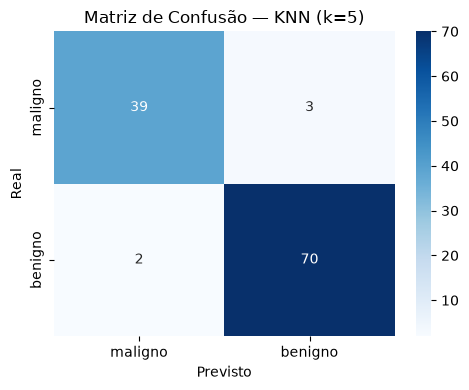

Falsos negativos (k=5): 3


In [49]:
from sklearn.metrics import accuracy_score, recall_score

# 1-3. Modelo inicial (k=5) treinado nos dados ESCALONADOS
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Relatório de classificação (k=5):\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["maligno", "benigno"], yticklabels=["maligno", "benigno"])
plt.title("Matriz de Confusão — KNN (k=5)")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

falsos_negativos_k5 = cm[0][1]  # maligno real, previsto como benigno
print(f"Falsos negativos (k=5): {falsos_negativos_k5}")



,k,acuracia,recall_maligno
0,1,0.938596,0.928571
1,2,0.929825,0.952381
2,3,0.982456,0.952381
3,4,0.947368,0.952381
4,5,0.956140,0.928571
5,6,0.956140,0.952381
6,7,0.973684,0.928571
7,9,0.973684,0.928571
8,12,0.973684,0.928571
9,15,0.973684,0.928571


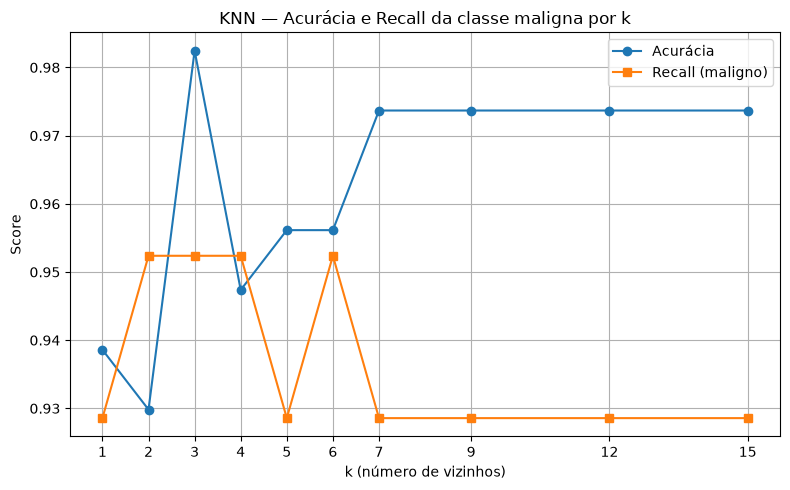

In [50]:
# 4. Testando múltiplos valores de k
k_values = [1,2,3,4, 5, 6, 7, 9,12, 15]
acuracias = []
recalls_maligno = []

for k in k_values:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_scaled, y_train)
    pred_k = modelo_k.predict(X_test_scaled)

    acuracias.append(accuracy_score(y_test, pred_k))
    # pos_label=0: recall da classe MALIGNA, não o padrão (classe 1)
    recalls_maligno.append(recall_score(y_test, pred_k, pos_label=0))

resultados_knn = pd.DataFrame({
    "k": k_values,
    "acuracia": acuracias,
    "recall_maligno": recalls_maligno
})
display(resultados_knn)

plt.figure(figsize=(8, 5))
plt.plot(k_values, acuracias, marker="o", label="Acurácia")
plt.plot(k_values, recalls_maligno, marker="s", label="Recall (maligno)")
plt.title("KNN — Acurácia e Recall da classe maligna por k")
plt.xlabel("k (número de vizinhos)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



**Respostas (Parte 3):**

- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?

Melhor avaliar o `Recall` que diz quantos acertos de malignos tivemos


- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


  Quando o `k` era 1, 5, +7 o recall caiu, a melhoe combinaçao foi com o `k` = 3 tendo um bom recall e acuracia

---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com relatório de classificação e matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.
5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?
6. Escolham a profundidade que vocês considerarem melhor e justifiquem.
7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.


,max_depth,acc_treino,acc_teste,recall_maligno
0,2,0.958242,0.894737,0.952381
1,4,0.986813,0.938596,0.928571
2,6,0.997802,0.912281,0.928571
3,None,1.000000,0.912281,0.928571


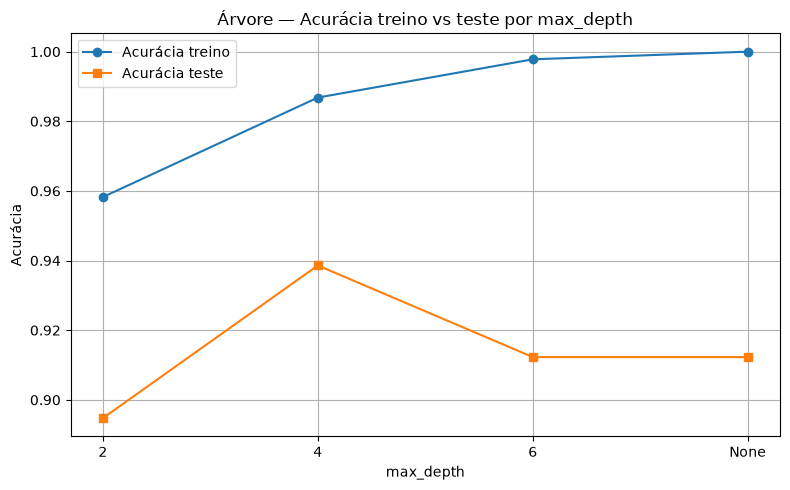

In [51]:
# 4-5. Testando múltiplos max_depth: acurácia de TREINO vs TESTE (evidencia overfitting)
profundidades = [2, 4, 6, None]
acc_treino = []
acc_teste = []
recall_maligno_arvore = []

for prof in profundidades:
    modelo_p = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo_p.fit(X_train, y_train)

    pred_treino = modelo_p.predict(X_train)
    pred_teste = modelo_p.predict(X_test)

    acc_treino.append(accuracy_score(y_train, pred_treino))
    acc_teste.append(accuracy_score(y_test, pred_teste))
    recall_maligno_arvore.append(recall_score(y_test, pred_teste, pos_label=0))

resultados_arvore = pd.DataFrame({
    "max_depth": [str(p) for p in profundidades],  # None misturado a int -> string para rotular
    "acc_treino": acc_treino,
    "acc_teste": acc_teste,
    "recall_maligno": recall_maligno_arvore
})
display(resultados_arvore)

plt.figure(figsize=(8, 5))
plt.plot(resultados_arvore["max_depth"], acc_treino, marker="o", label="Acurácia treino")
plt.plot(resultados_arvore["max_depth"], acc_teste, marker="s", label="Acurácia teste")
plt.title("Árvore — Acurácia treino vs teste por max_depth")
plt.xlabel("max_depth")
plt.ylabel("Acurácia")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [52]:
# 6. Escolha da profundidade: maior recall da classe maligna, evitando overfitting extremo
melhor_prof_idx = resultados_arvore["recall_maligno"].idxmax()
melhor_profundidade = resultados_arvore.loc[melhor_prof_idx, "max_depth"]
print(f"\nmax_depth escolhida: {melhor_profundidade} (maior recall da classe maligna)")






max_depth escolhida: 2 (maior recall da classe maligna)


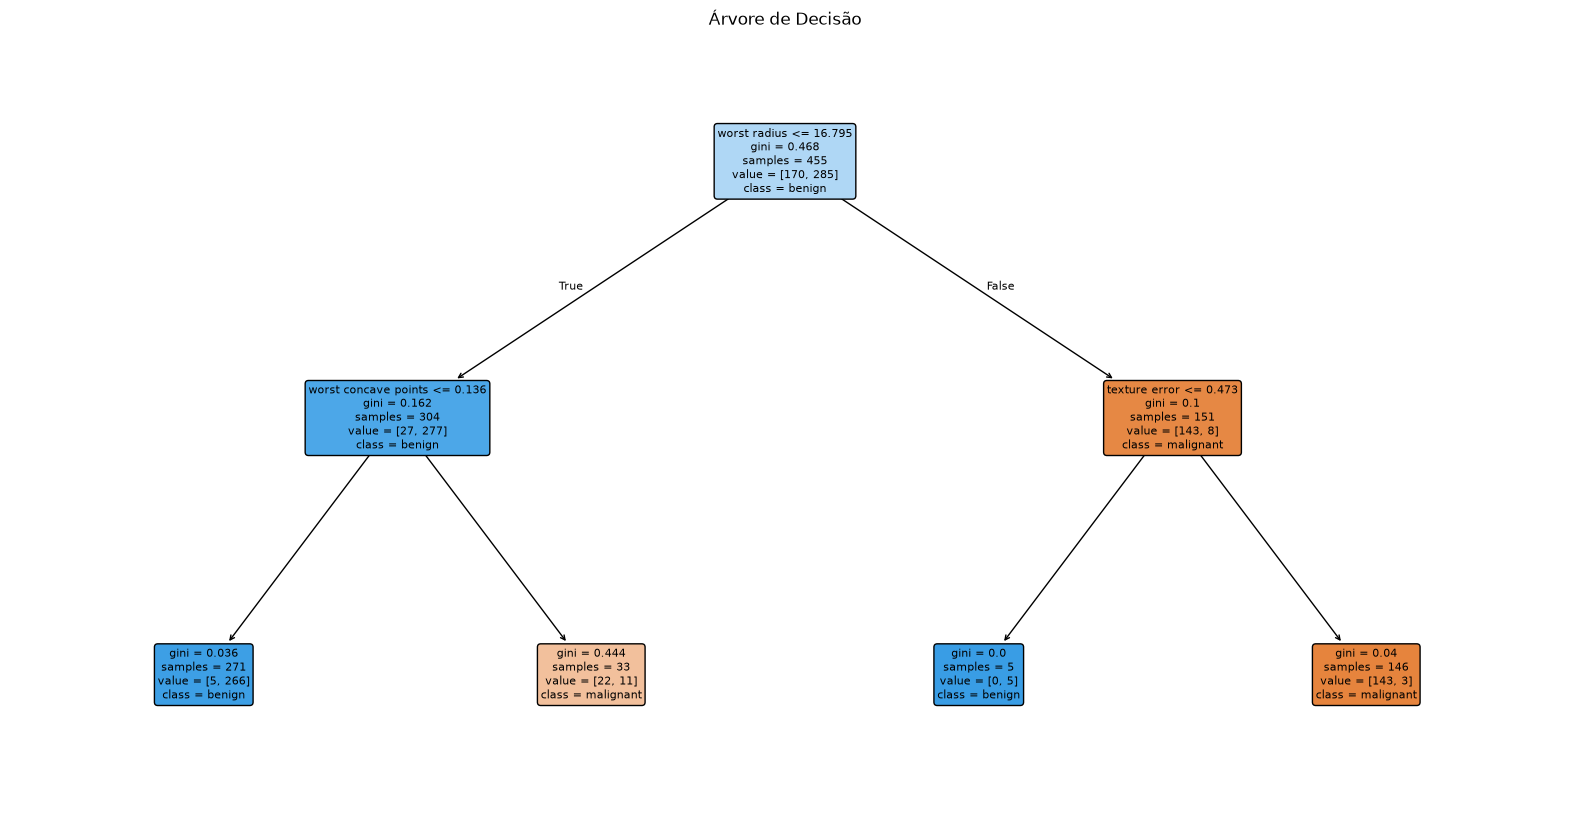

In [53]:
# --- Visualização da árvore 
# Ajuste "arvore_final" para o nome da variável do seu modelo já treinado com X_train/y_train
plt.figure(figsize=(20, 10))
plot_tree(
    arvore_final,
    feature_names=X.columns,           # nomes reais das 30 medidas, não "X[0]", "X[1]"...
    class_names=data.target_names,     # "malignant"/"benign" em vez de 0/1
    filled=True,                       # colore cada caixa pela classe majoritária
    rounded=True,
    fontsize=8
)
plt.title("Árvore de Decisão")
plt.show()

**Respostas (Parte 4):**

*Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?

No treino ela foi melhor (chegou perto de 100% de acerto), mas no teste foi igual ou pior que
uma árvore mais rasa. Isso mostra que ela "decorou" os dados de treino em vez de aprender um
padrão geral — cada folha virou quase uma amostra específica. Esse comportamento é o
**overfitting**: o modelo fica ótimo nos dados que já viu e perde a capacidade de generalizar
para dados novos.

- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?


  A Árvore de Decisão. Ela mostra um fluxograma de perguntas simples ("essa medida é maior ou
menor que X?") até chegar no diagnóstico, então dá para seguir o caminho e apontar exatamente
o motivo da decisão. O KNN não tem essa explicação direta: ele só diz "os vizinhos mais
parecidos com esse paciente eram malignos", sem mostrar um raciocínio passo a passo.

---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

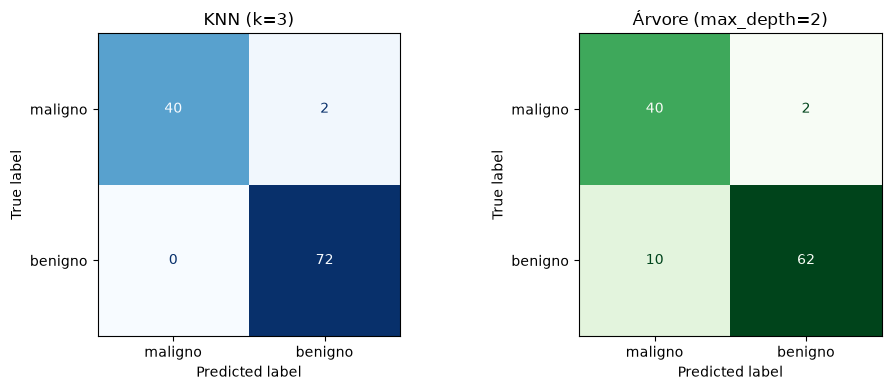

In [54]:
# Modelos finais: KNN com k=3 e Árvore com max_depth=2 (já treinada em arvore_final)
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train_scaled, y_train)
pred_knn = knn_final.predict(X_test_scaled)
pred_arvore = arvore_final.predict(X_test)

# 1. Matrizes de confusão lado a lado
cm_knn = confusion_matrix(y_test, pred_knn, labels=[0, 1])
cm_arvore = confusion_matrix(y_test, pred_arvore, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_knn, display_labels=["maligno", "benigno"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("KNN (k=3)")
ConfusionMatrixDisplay(cm_arvore, display_labels=["maligno", "benigno"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Árvore (max_depth=2)")
plt.tight_layout()
plt.show()




In [55]:
# 2. Tabela comparativa de métricas
rel_knn = classification_report(y_test, pred_knn, target_names=data.target_names, output_dict=True)
rel_arvore = classification_report(y_test, pred_arvore, target_names=data.target_names, output_dict=True)

comparacao = pd.DataFrame({
    "KNN (k=3)": {
        "accuracy": rel_knn["accuracy"],
        "precision_maligno": rel_knn["malignant"]["precision"],
        "recall_maligno": rel_knn["malignant"]["recall"],
        "f1_maligno": rel_knn["malignant"]["f1-score"],
    },
    "Árvore (depth=2)": {
        "accuracy": rel_arvore["accuracy"],
        "precision_maligno": rel_arvore["malignant"]["precision"],
        "recall_maligno": rel_arvore["malignant"]["recall"],
        "f1_maligno": rel_arvore["malignant"]["f1-score"],
    },
}).round(3)
display(comparacao)



,KNN (k=3),Árvore (depth=2)
accuracy,0.982,0.895
precision_maligno,1.000,0.800
recall_maligno,0.952,0.952
f1_maligno,0.976,0.870


In [56]:
# 3. Falsos negativos (maligno real -> previsto benigno)
fn_knn = cm_knn[0][1]
fn_arvore = cm_arvore[0][1]
print(f"Falsos negativos — KNN: {fn_knn} | Árvore: {fn_arvore}")

Falsos negativos — KNN: 2 | Árvore: 2


**Respostas (Parte 5):**

**Qual modelo teve o menor número de falsos negativos?**

Empate: KNN (k=3) e Árvore (max_depth=2) cometeram os mesmos **2 falsos negativos** em 42 casos
malignos do teste (recall_maligno = 0,952 nos dois). A diferença real está nos **falsos
positivos** — a Árvore errou 10 benignos classificados como malignos, o KNN não errou nenhum.

**Existe um modelo que "ganhou" em todas as métricas, ou há um trade-off?**


Neste caso o KNN ganhou em quase tudo: accuracy (0,982 vs 0,895), precision_maligno (1,00 vs
0,80) e f1_maligno (0,976 vs 0,870), empatando só no recall_maligno. Não há trade-off — a
árvore rasa (depth=2, só 2 níveis de corte) segura o recall mas sacrifica muita precisão.


---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.
2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?
4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?
5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

### ✍️ Relatório

**Nomes:** Henrique Tamaki

**1. Recomendação:**

Recomendamos o **KNN (k=3)** para apoiar o diagnóstico. Ele teve mais acertos no geral (98,2%
contra 89,5% da Árvore) e, mais importante, não classificou nenhum tumor benigno como maligno
por engano. Os dois modelos erraram a mesma quantidade de casos malignos (2 em 42), então nesse
ponto mais crítico eles empatam. Já na classificação de benigno acertou todos, trazendo menos ruido e controle para o processo em revisões.

**2. Riscos de cada modelo:**

Os dois modelos deixaram passar 2 tumores malignos como se fossem benignos (falso negativo),
que é o erro mais grave. Portanto o modelo não é perfeito e toda recomendação do modelo como benigno precisa ser revisado pelo corpo médico para a validação humana. Quando a arvore classifica errado os benigno como maligno gera a necessidade de validação medica, exames, consultas e pressão emocional aos pacientes.



**3. Interpretabilidade:**

A Árvore de Decisão é mais fácil de explicar: dá para mostrar o desenho da árvore e dizer
"o modelo decidiu maligno porque essa medida do tumor era maior que tal valor". O KNN não
explica o motivo, só diz que o caso se parece com outros pacientes malignos já vistos. 

Portanto o corpo médico entenderia muito mais facilmente a lógica da Arvore, mas devido aos resultados expressivamente superiores a dificuldade de interpretação se justifica pelos ganhos.

**4. Limitações do estudo:**

A base tem só 569 pacientes (114 no teste), um número pequeno para conclusões definitivas. Só
foi testada uma divisão treino/teste(80/20). Para esta finalidade o cenário ideal seria ter milhares de dados realizando validação cruzada entre as fatias para termos resultados do mesmo modelo e desta forma aferirmos os valores de acerto.

Alem disso o modelo deve ser utilizado somente para apoiar o medico e agilizar o processo de diagnostico e pode ser escalado para outros hospitais e clinicas sem aumento do corpo medico, nunca eliminando a responsabilidade do medico em fazer o diagnostico real aos pacientes.


**5. Próximos passos:**
Com mais tempo, testaríamos validação cruzada para confirmar se o KNN realmente é o melhor,
experimentaríamos outros algoritmos (ex: Regressão Logística, Random Forest).


Implementar modelo como beta para alguns medicos e a equipe de dados acompanhara o funcionamento com o feedback do corpo clinico para ajustes, correções e coleta de dados reais.


---
## ✅ Critérios de Entrega

Ao final das 2h30min, deverá ser entregue este notebook com:

- [X] Todas as células de código executadas sem erro, do início ao fim;
- [X] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [X] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [X] Matrizes de confusão comparativas dos dois modelos;
- [X] Tabela comparativa de métricas;
- [X] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [X] Relatório final (Parte 6) preenchido.
